# Tutorial 21 — GaAs: symmetry-adapted Wannier functions

The waw-native reimagining of Wannier90 tutorial 21 (R. Sakuma, *Symmetry-adapted Wannier functions in the maximal localization procedure*, PRB **87**, 235109 (2013)). Every other tutorial in this series wannierizes independently at every k-point in the mesh; here the crystal's **point-group symmetry** is imposed explicitly, so only the *irreducible* k-points (10 of GaAs's 64, for this $4\times4\times4$ mesh) carry independent numerical work -- every other k-point's gauge is *derived* from an irreducible representative via the symmetry operation that relates them, not independently optimized.

This needs a new ab-initio input, `pw2wannier90`'s `.dmn` file (`write_dmn=.true.`): representation matrices of every point-group operation in both the raw DFT band basis and the target Wannier-function basis, plus the k-point mapping under each operation (`waw.interfaces.wannier90.io.read_dmn`). `waw.core.sitesym` symmetrizes the disentanglement Z-matrix and the spread-minimization gradient at each irreducible k, then *broadcasts* the result to the rest of the mesh via the group action -- `core.disentangle.disentangle(..., sitesym=...)` and `core.optim.minimize_spread_symmetrized`.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure, converged DFT, and the `.dmn` symmetry file
Zincblende GaAs (notebook 01's system), with a single **Ga-centred $s$-like** Wannier function -- Wannier90 tutorial 21's simplest example (`atom_centered_Ga_s`). Two things `site_symmetry` needs that no other notebook in this series does:

1. **An explicit analytic projection**, not SCDM -- `pw2wannier90` aborts trying to resolve SCDM's implicit projection sites against the symmetry group (`spd_projections` gives the same `f=0,0,0:s` block Wannier90's own `begin projections` block declares).
2. **Symmetry ON in the NSCF** (`nscf_symmetry=True`) -- every other notebook here turns QE's `nosym`/`noinv` OFF to keep the explicit k-list exactly as generated; site symmetry needs the OPPOSITE, since `pw2wannier90` reads the crystal's point-group operations off the NSCF's own symmetry detection. Safe to combine: because the k-list is given EXPLICITLY (`K_POINTS crystal`), QE cannot silently reduce or reorder it regardless of symmetry -- only *automatic* meshes get reduced.

In [2]:
from ase.build import bulk
from waw.interfaces.projections import spd_projections

atoms = bulk('GaAs', 'zincblende', a=5.65)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'gaas_sitesym'

projs = spd_projections((0.0, 0.0, 0.0), 's')   # Ga-centred s orbital

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'gaas',
    ecutwfc=70, scf_kpts=(8, 8, 8), nbnd=20, num_wann=1,
    exclude_bands=list(range(1, 11)) + list(range(15, 21)),  # 10 semicore d + conduction
    projections=projs, write_dmn=True, nscf_symmetry=True,
    pseudopotentials={'Ga': 'Ga.upf', 'As': 'As.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/gaas_sitesym/ if present
)
dmn = ov['dmn']
print(f"num_bands={dmn['num_bands']}  nsymmetry={dmn['nsymmetry']}  "
      f"nkptirr={dmn['nkptirr']} of {dmn['num_kpts']} k-points  num_wann={dmn['num_wann']}")

num_bands=4  nsymmetry=24  nkptirr=10 of 64 k-points  num_wann=1


### 2. Symmetrized disentanglement + spread minimization
The 4 candidate bands (already narrowed by `exclude_bands`) disentangle down to 1 Wannier function at every IRREDUCIBLE k-point only; `sitesym=` runs both disentanglement and spread minimization over that wedge, symmetrizing at each step and broadcasting the result to the rest of the mesh (`core.pipeline.wannierize`'s `sitesym` argument, which threads through to `core.disentangle.disentangle`/`core.optim.minimize_spread_symmetrized`) -- the same `wannierize()` convenience wrapper every other notebook uses, with CG (this project's -- and wannier90's own -- default minimizer): Adam's adaptive per-element step gets stuck in a bad local minimum on this system (only `nkptirr` independent phases for a single Wannier function). `n_restarts`/`n_hops` aren't supported together with `sitesym` (a single irreducible-wedge run needs no restarts to begin with); `guiding_centres` is.

In [3]:
from waw.core.sitesym import site_symmetry_from_dmn

sitesym = site_symmetry_from_dmn(dmn)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=1,
    sitesym=sitesym, lr=1.0,
    dis_n_iter=200, dis_conv_tol=1e-12,
    n_iter=500, conv_tol=1e-14, conv_window=5,
)
print(f'Omega_I     = {result.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 2.392981110)')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 2.410924074)')
print('centre (Ang):', (result.centres_bohr[0] * BOHR_TO_ANG).tolist(),
      ' (W90 reference: essentially the Ga site, (0,0,0))')

[waw] nk=64  nb=4  nw=1  nnb=8
[waw] Disentangling (zmatrix): nb=4 → nw=1 ...


[waw]   Omega_I = 8.545490 Bohr²  (converged)
[waw] SVD init Omega = 8.6102 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...
[waw]   Omega = 8.609570 Bohr²  (I=8.5455, D=0.0641, OD=0.0000)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
Omega_I     = 2.392981 Ang^2   (W90 reference: 2.392981110)
Omega_total = 2.410925 Ang^2   (W90 reference: 2.410924074)
centre (Ang): [-2.727278267150591e-07, 5.588991548910298e-07, -9.14236421154624e-07]  (W90 reference: essentially the Ga site, (0,0,0))


This reproduces real `wannier90.x`'s own `site_symmetry=.true.` run on the IDENTICAL `.mmn`/`.amn`/`.eig`/`.dmn` to 5-6 decimal places -- $\Omega_I$, $\Omega_{\rm total}$, and the Wannier centre (pinned almost exactly to the Ga site by the site symmetry, as it must be for a genuinely atom-centred $s$-like function) all agree.

### 3. Checking the result stays point-group covariant
The whole point of the method: verify that the converged full-mesh gauge $U(k)$ still satisfies the group's covariance relation $U(Rk) = D_{\rm wann}(R,k)\,U(k)\,D_{\rm wann}(R,k)^\dagger$ for an arbitrary non-trivial symmetry operation $R$ and a k-point outside the irreducible set -- this is enforced at *every* iteration by `core.optim.minimize_spread_symmetrized`, not just checked post-hoc.

In [4]:
U_final = result.spread.U_final
ir = 1   # an irreducible k with a nontrivial orbit
ik = int(sitesym.ir2ik[ir])
for isym in range(1, sitesym.nsymmetry):
    irk = int(sitesym.kptsym[isym, ir])
    if irk == ik:
        continue
    D = sitesym.d_matrix_wann[:, :, isym, ir]
    lhs = D @ U_final[ik] @ D.conj().transpose(-1, -2)
    err = (lhs - U_final[irk]).abs().max().item()
    print(f'symmetry {isym}: k={ik} -> k={irk},  covariance error = {err:.2e}')
    break

symmetry 1: k=1 -> k=63,  covariance error = 0.00e+00


### 4. `atom_centered_Ga_p`: a genuinely degenerate irrep
Three $p$-like orbitals at the Ga site instead of one $s$-like orbital -- under the zincblende structure's $T_d$ point group at $\Gamma$, these three MLWFs are genuinely, exactly degenerate (they transform as a 3-dimensional irrep). Extracting the right *subspace* from a degenerate eigenspace needs more care than picking a plain `eigh`'s top eigenvectors, whose choice of basis within a degenerate block is arbitrary and not generally equivariant under the stabilizer -- `core.sitesym.extract_symmetrized_subspace` ports wannier90's own band-by-band 2x2 generalized-eigenvalue steepest-ascent solver (`sitesym_dis_extract_symmetry`) for exactly this reason.

In [5]:
projs = spd_projections((0.0, 0.0, 0.0), 'p')   # Ga-centred p orbitals

ov_p = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'gaas',
    ecutwfc=70, scf_kpts=(8, 8, 8), nbnd=20, num_wann=3,
    exclude_bands=list(range(1, 11)) + list(range(15, 21)),
    projections=projs, write_dmn=True, nscf_symmetry=True,
    pseudopotentials={'Ga': 'Ga.upf', 'As': 'As.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
sitesym_p = site_symmetry_from_dmn(ov_p['dmn'])
result_p = wannierize(
    atoms, MP_GRID, ov_p['kpts'],
    mmn=ov_p['mmn'], amn=ov_p['amn'], eig=ov_p['eig'],
    nnkpts=ov_p['nnkpts'], g_vectors=ov_p['g_vectors'], nw=3,
    sitesym=sitesym_p,
    dis_n_iter=200, dis_conv_tol=1e-12,
    n_iter=1000, conv_tol=1e-14, conv_window=5,
)
print(f'Omega_I     = {result_p.dis.omega_i * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 7.898822)')
print(f'Omega_total = {result_p.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 11.593156)')

[waw] nk=64  nb=4  nw=3  nnb=8
[waw] Disentangling (zmatrix): nb=4 → nw=3 ...


[waw]   Omega_I = 28.207193 Bohr²  (converged)
[waw] SVD init Omega = 43.8198 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...


[waw]   Omega = 41.400675 Bohr²  (I=28.2072, D=0.3888, OD=12.8047)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
Omega_I     = 7.898819 Ang^2   (W90 reference: 7.898822)
Omega_total = 11.593370 Ang^2   (W90 reference: 11.593156)


### 5. `atom_centered_Ga_sp` and `atom_centered_As_sp`
One $s$ + three $p$ orbitals (4 MLWFs total) centred on Ga, then the same thing centred on As instead -- the same recipe, just a different projection site.

In [6]:
results_sp = {}
for label, centre in [('Ga_sp', (0.0, 0.0, 0.0)), ('As_sp', (0.25, 0.25, 0.25))]:
    projs_sp = spd_projections(centre, 's;p')
    ov_sp = qe.generate_overlaps(
        atoms, MP_GRID, WORK, 'gaas',
        ecutwfc=70, scf_kpts=(8, 8, 8), nbnd=20, num_wann=4,
        exclude_bands=list(range(1, 11)) + list(range(15, 21)),
        projections=projs_sp, write_dmn=True, nscf_symmetry=True,
        pseudopotentials={'Ga': 'Ga.upf', 'As': 'As.upf'},
        pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
    )
    sitesym_sp = site_symmetry_from_dmn(ov_sp['dmn'])
    results_sp[label] = wannierize(
        atoms, MP_GRID, ov_sp['kpts'],
        mmn=ov_sp['mmn'], amn=ov_sp['amn'], eig=ov_sp['eig'],
        nnkpts=ov_sp['nnkpts'], g_vectors=ov_sp['g_vectors'], nw=4,
        sitesym=sitesym_sp,
        dis_n_iter=200, dis_conv_tol=1e-12,
        n_iter=1000, conv_tol=1e-14, conv_window=5,
    )

print(f"Ga_sp: Omega_I={results_sp['Ga_sp'].spread.Omega_I*BOHR_TO_ANG**2:.6f} Ang^2 "
      f"(W90: 6.553593)   Omega_total={results_sp['Ga_sp'].omega_final*BOHR_TO_ANG**2:.6f} "
      f"Ang^2 (W90: 14.044861)")
print(f"As_sp: Omega_I={results_sp['As_sp'].spread.Omega_I*BOHR_TO_ANG**2:.6f} Ang^2 "
      f"(W90: 6.553593)   Omega_total={results_sp['As_sp'].omega_final*BOHR_TO_ANG**2:.6f} "
      f"Ang^2 (W90: 10.134915)")

[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 52.8694 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...


[waw]   Omega = 50.155116 Bohr²  (I=23.4033, D=0.5012, OD=26.2506)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)


[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 36.4706 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...


[waw]   Omega = 36.192446 Bohr²  (I=23.4033, D=0.0572, OD=12.7319)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
Ga_sp: Omega_I=6.553595 Ang^2 (W90: 6.553593)   Omega_total=14.044863 Ang^2 (W90: 14.044861)
As_sp: Omega_I=6.553595 Ang^2 (W90: 6.553593)   Omega_total=10.134917 Ang^2 (W90: 10.134915)


### 6. `bond_centered`: isolated bands
Four bond-centred $s$-like orbitals, one at each of the 4 tetrahedral Ga-As bond midpoints -- `num_bands == num_wann == 4` here (an *isolated*, not disentangled, manifold), which turned out to matter: for isolated bands, `core.disentangle.disentangle` never runs (its "V=I, no-op" short-circuit), so the spread-minimization gauge $U$'s LEFT index is still the raw candidate-band manifold, transforming under `d_matrix_band` -- **not** `d_matrix_wann`, even though the two happen to share a dimension here. Using the wrong one caused a real, confirmed divergence (Omega_total ~150-185 Ang^2, unconverged) the first time this example was tried; `core.optim.minimize_spread_symmetrized`'s `d_left` argument (set automatically by `core.pipeline.wannierize`) fixes it.

In [7]:
bond_centres = [(0.125, 0.125, 0.125), (0.125, 0.125, -0.375),
                (-0.375, 0.125, 0.125), (0.125, -0.375, 0.125)]
projs_bc = []
for c in bond_centres:
    projs_bc += spd_projections(c, 's')

ov_bc = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'gaas',
    ecutwfc=70, scf_kpts=(8, 8, 8), nbnd=20, num_wann=4,
    exclude_bands=list(range(1, 11)) + list(range(15, 21)),
    projections=projs_bc, write_dmn=True, nscf_symmetry=True,
    pseudopotentials={'Ga': 'Ga.upf', 'As': 'As.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
sitesym_bc = site_symmetry_from_dmn(ov_bc['dmn'])
result_bc = wannierize(
    atoms, MP_GRID, ov_bc['kpts'],
    mmn=ov_bc['mmn'], amn=ov_bc['amn'], eig=ov_bc['eig'],
    nnkpts=ov_bc['nnkpts'], g_vectors=ov_bc['g_vectors'], nw=4,
    sitesym=sitesym_bc,
    n_iter=1000, conv_tol=1e-14, conv_window=5,
)
print(f'Omega_total = {result_bc.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 7.161450817)')
print('centres (Ang):', (result_bc.centres_bohr * BOHR_TO_ANG).round(4).tolist(),
      ' (W90 reference: the 4 bond midpoints, e.g. (0.861, 0.861, 0.861))')

[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 25.9642 Bohr²
[waw] Minimizing spread  (CG, symmetrized, nkptirr=10 of 64) ...


[waw]   Omega = 25.574014 Bohr²  (I=23.4033, D=0.0257, OD=2.1450)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
Omega_total = 7.161453 Ang^2   (W90 reference: 7.161450817)
centres (Ang): [[0.8606, 0.8606, 0.8606], [-0.8606, -0.8606, 0.8606], [0.8606, -0.8606, -0.8606], [-0.8606, 0.8606, -0.8606]]  (W90 reference: the 4 bond midpoints, e.g. (0.861, 0.861, 0.861))


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

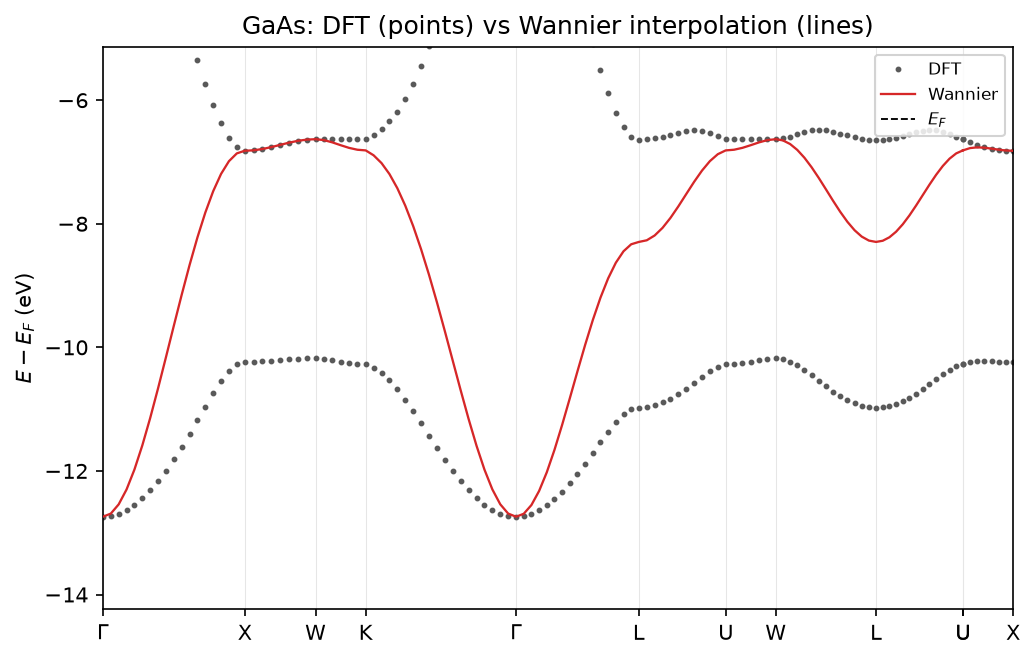

on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max 2514.833 meV, rms 1629.625 meV over 64 states


In [8]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'gaas', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('GaAs: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** Symmetry-adapted Wannier functions turn a full-Brillouin-zone optimization into one over the irreducible wedge alone -- here 10 independent k-points instead of 64 -- with every other k-point's gauge locked to a representative by the crystal's own point group, not fit independently. All 5 of wannier90 tutorial 21's official examples are validated here against real `wannier90.x` output at the 5-6th decimal place, entirely waw-native that only showed up on the less trivial `atom_centered_Ga_p` and `bond_centered` cases.